# Proyección de ventas — April Collections

**Ciencia de Datos II · Grupo 5 · Sección 77**
Kevin Zúniga · Nahún Reyes · Wilmer Sánchez

---

Este cuaderno proyecta las ventas mensuales del negocio para responder una pregunta
operativa concreta:

> **¿Cuánto inventario hay que comprar para el mes que viene?**

En un negocio de venta por catálogo la mercadería se encarga con semanas de antelación.
Comprar de menos significa perder ventas que ya estaban hechas; comprar de más significa
dejar capital inmovilizado en producto que no rota. Una estimación razonable del volumen
del próximo mes vale dinero real.

## Advertencia sobre el alcance

La serie tiene **24 meses**, es decir **dos ciclos anuales**. Ese es el mínimo absoluto
para que un modelo estacional pueda siquiera estimar un patrón, y significa que cada mes
del año está representado por **solo dos observaciones**.

Con esa base, la proyección sirve como **orden de magnitud para planificar compras**, no
como una cifra exacta. Cualquier lectura más ambiciosa sería deshonesta, y se dice aquí
antes de mostrar un solo número.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

FIGURAS = RAIZ / "docs" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

ROSA, ROSA_OSCURO, ORO, VERDE, GRIS = "#c8697a", "#9e3f52", "#c9a96e", "#4a9e7a", "#7a6570"

plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110, "savefig.dpi": 160,
    "savefig.bbox": "tight", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def guardar(nombre):
    plt.savefig(FIGURAS / f"{nombre}.png")
    plt.show()

---
## 1. Construcción de la serie

Se suman **todas** las ventas del mes, no solo las fiadas: para planificar inventario
importa cuánto producto sale, se haya cobrado al contado o a crédito.

In [2]:
from etl.extraer import extraer
from etl.transformar import totales_por_venta

tablas = extraer()
ventas = tablas["ventas"].merge(
    totales_por_venta(tablas["venta_items"]), left_on="id", right_index=True, how="inner"
)
ventas["mes"] = ventas["fecha"].dt.to_period("M")

mensual = ventas.groupby("mes").agg(
    vendido=("total_centavos", "sum"),
    ventas=("id", "size"),
    articulos=("articulos", "sum"),
)
mensual["vendido"] = mensual["vendido"] / 100

print(mensual.to_string(float_format=lambda x: f"{x:,.0f}"))

         vendido  ventas  articulos
mes                                
2024-10    9,520       6         15
2024-11   30,170      15         41
2024-12   53,160      35         71
2025-01   24,040      16         35
2025-02   60,620      40         90
2025-03   81,850      57        123
2025-04   96,780      74        137
2025-05  200,260     128        288
2025-06  168,930     111        243
2025-07  193,530     138        281
2025-08  222,760     142        326
2025-09  226,740     155        323
2025-10  301,570     196        412
2025-11  306,130     213        458
2025-12  579,860     400        867
2026-01  199,190     145        290
2026-02  223,360     136        331
2026-03  396,580     267        585
2026-04  352,850     250        532
2026-05  543,020     389        817
2026-06  349,520     233        494
2026-07  367,640     236        550
2026-08  429,260     292        626
2026-09    4,900       4          9


### El último mes está incompleto, y hay que quitarlo

El mes final de la serie no cubre treinta días: los datos se cortan a mitad de mes.
Dejarlo dentro mostraría un **desplome del 99%** que no es una caída del negocio sino un
artefacto de dónde termina el conjunto de datos.

Es un error frecuente y caro: el modelo aprendería que el negocio se derrumba, y la
proyección del mes siguiente saldría absurdamente baja. Se identifica comparando el volumen
del último mes con la mediana de los anteriores.

In [3]:
# Un mes cuyo volumen sea menos de la mitad de la mediana reciente esta,
# casi con seguridad, incompleto.
referencia = mensual["vendido"].tail(7).median()
ultimo = mensual.index[-1]

if mensual.loc[ultimo, "vendido"] < referencia * 0.5:
    print(f"  {ultimo} parece incompleto: "
          f"L {mensual.loc[ultimo, 'vendido']:,.0f} frente a una mediana reciente "
          f"de L {referencia:,.0f}")
    print("  -> se excluye de la serie")
    mensual = mensual.iloc[:-1]

# Los primeros meses son el arranque del negocio, no su comportamiento normal:
# la clientela se iba incorporando. Se conservan para ver la tendencia, pero
# conviene tenerlo presente al leer la serie.
serie = mensual["vendido"]
serie.index = serie.index.to_timestamp()

print(f"\n  serie final: {len(serie)} meses, de {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m}")

  2026-09 parece incompleto: L 4,900 frente a una mediana reciente de L 367,640
  -> se excluye de la serie

  serie final: 23 meses, de 2024-10 a 2026-08


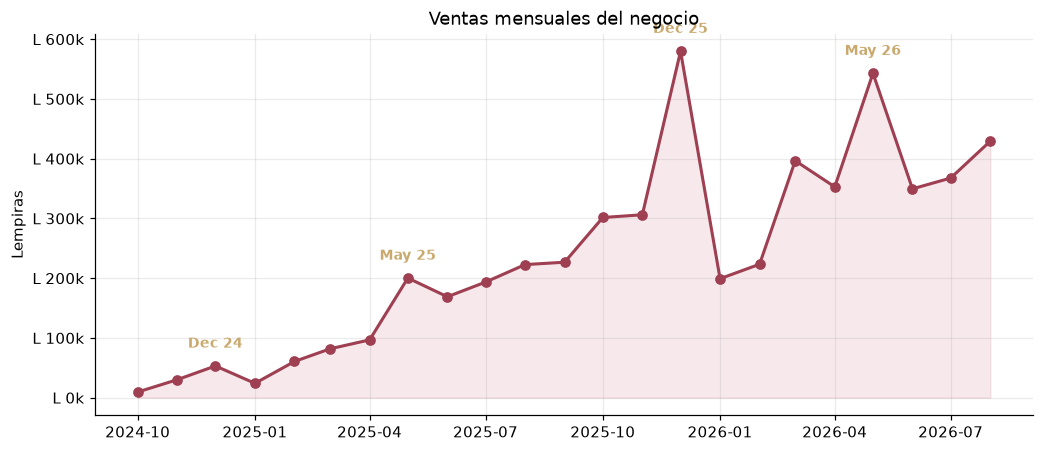

In [4]:
fig, eje = plt.subplots(figsize=(11, 4.5))
eje.plot(serie.index, serie.values, marker="o", color=ROSA_OSCURO, linewidth=2)
eje.fill_between(serie.index, serie.values, alpha=0.15, color=ROSA)

# Se marcan los meses fuertes: dia de la madre y navidad.
for fecha, valor in serie.items():
    if fecha.month in (5, 12):
        eje.annotate(f"{fecha:%b %y}", (fecha, valor), textcoords="offset points",
                     xytext=(0, 12), ha="center", fontsize=9, color=ORO, weight="bold")

eje.set_title("Ventas mensuales del negocio")
eje.set_ylabel("Lempiras")
eje.yaxis.set_major_formatter(lambda x, _: f"L {x/1000:,.0f}k")

guardar("14_serie_mensual")

---
## 2. Descomposición: tendencia, estacionalidad y ruido

Separar la serie en sus componentes muestra qué parte del movimiento es crecimiento
sostenido, qué parte se repite cada año y qué parte es simplemente irregular.

Se usa descomposición **multiplicativa** porque la estacionalidad crece con el nivel de la
serie: diciembre no suma una cantidad fija, sino que multiplica lo que haya. Es lo típico en
ventas.

### Por qué se hace a mano

`seasonal_decompose` de statsmodels **se niega a trabajar con esta serie**:

```
ValueError: x must have 2 complete cycles requires 24 observations.
x only has 23 observation(s)
```

Al quitar el mes incompleto quedan 23 meses, uno menos del mínimo que exige. La tentación
sería devolver ese mes a la serie para llegar a 24 — y sería falsear los datos para
satisfacer a una librería.

Se hace en su lugar la **descomposición clásica por cociente sobre la media móvil**, que es
el método que implementa esa misma función y que sí puede aplicarse aquí:

1. La **tendencia** es la media móvil centrada de doce meses.
2. Dividir la serie entre su tendencia deja la parte **estacional más el ruido**.
3. Promediar ese cociente por mes del año da el **índice estacional** de cada mes.
4. Lo que queda tras quitar tendencia y estacionalidad es el **residuo**.

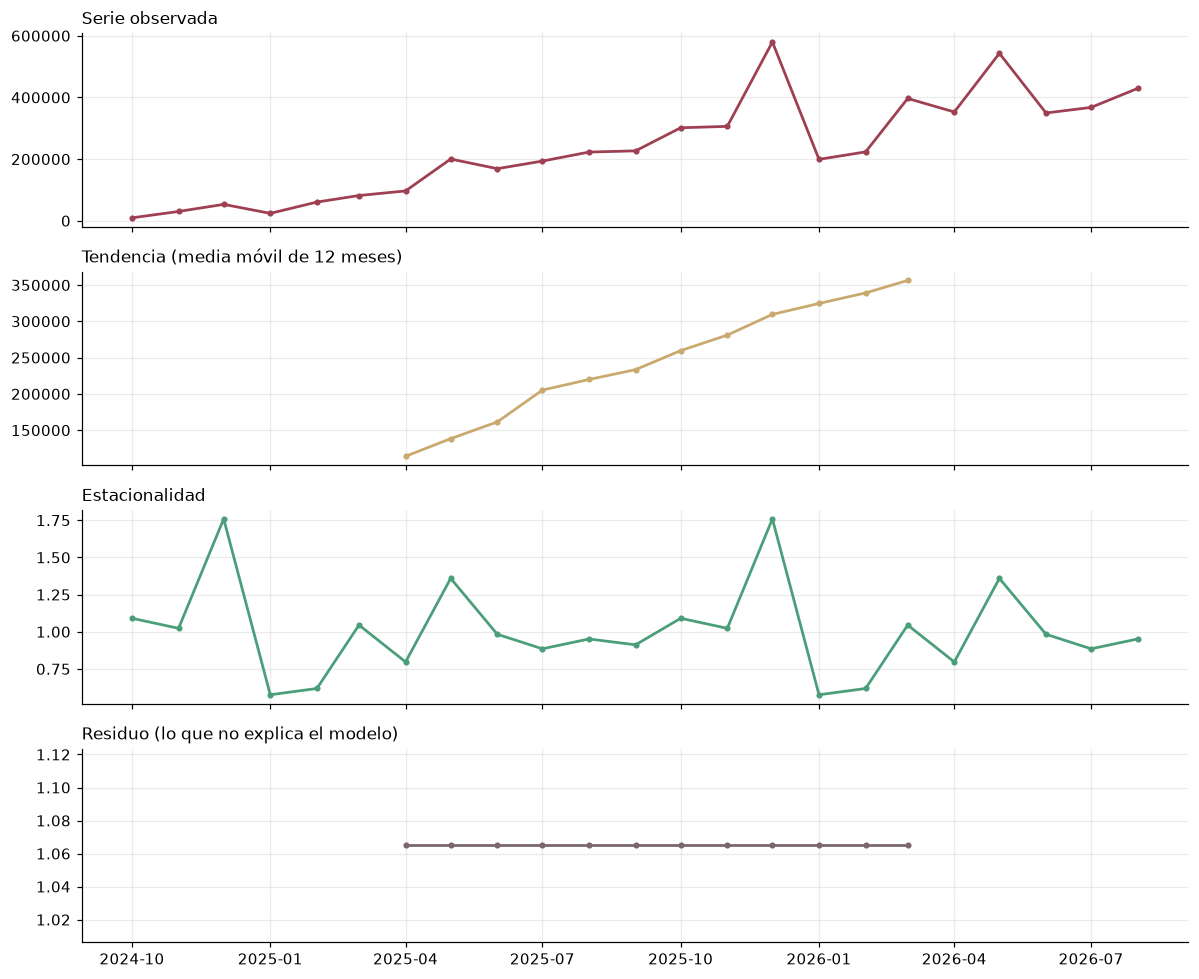

  meses con tendencia estimable: 12 de 23
  (la media movil no puede calcularse en los extremos de la serie)


In [5]:
# 1. Tendencia: media movil centrada de 12 meses.
tendencia = serie.rolling(window=12, center=True).mean()

# 2. Quitar la tendencia deja estacionalidad + ruido.
sin_tendencia = serie / tendencia

# 3. El indice de cada mes es el promedio de lo que le toco en los años vistos.
indices = sin_tendencia.groupby(sin_tendencia.index.month).mean()
# Se normalizan para que un año completo multiplique por 1 y no infle el nivel.
indices = indices / indices.mean()

estacional = pd.Series(
    [indices[fecha.month] for fecha in serie.index], index=serie.index)

# 4. Lo que no explican ni la tendencia ni la estacionalidad.
residuo = serie / (tendencia * estacional)

fig, ejes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

for eje, (datos, titulo, color) in zip(ejes, [
    (serie, "Serie observada", ROSA_OSCURO),
    (tendencia, "Tendencia (media móvil de 12 meses)", ORO),
    (estacional, "Estacionalidad", VERDE),
    (residuo, "Residuo (lo que no explica el modelo)", GRIS),
]):
    eje.plot(datos.index, datos.values, marker="o", markersize=3, color=color, linewidth=1.8)
    eje.set_title(titulo, fontsize=11, loc="left")

plt.tight_layout()
guardar("15_descomposicion")

print(f"  meses con tendencia estimable: {tendencia.notna().sum()} de {len(serie)}")
print("  (la media movil no puede calcularse en los extremos de la serie)")

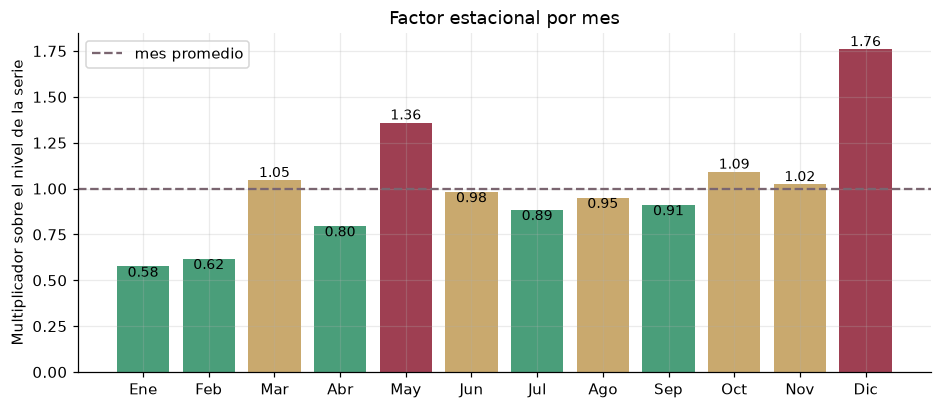

,factor
Ene,0.576
Feb,0.618
Mar,1.045
Abr,0.797
May,1.359
Jun,0.983
Jul,0.885
Ago,0.951
Sep,0.912
Oct,1.091


In [6]:
# El factor estacional de cada mes: cuanto multiplica respecto a un mes normal.
factores = indices.copy()
factores.index = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                  "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

fig, eje = plt.subplots(figsize=(10, 4))
colores = [VERDE if f < 0.95 else ORO if f < 1.15 else ROSA_OSCURO for f in factores]
eje.bar(factores.index, factores.values, color=colores)
eje.axhline(1.0, color=GRIS, linestyle="--", label="mes promedio")
eje.set_title("Factor estacional por mes")
eje.set_ylabel("Multiplicador sobre el nivel de la serie")
eje.legend()

for i, valor in enumerate(factores.values):
    eje.text(i, valor, f"{valor:.2f}", ha="center",
             va="bottom" if valor >= 1 else "top", fontsize=9)

guardar("16_factores_estacionales")
factores.round(3).to_frame("factor")

**Los picos coinciden con lo que cualquiera esperaría del negocio**: mayo por el día de la
madre y diciembre por navidad. Enero y febrero caen, después del gasto navideño.

Que el modelo recupere por su cuenta un patrón que la dueña ya conoce es una buena señal:
indica que está leyendo la estructura real de la serie y no ruido.

**Pero cuidado con la precisión de estos factores.** Cada uno se estima a partir de **dos
observaciones** — un mayo y otro mayo. Son suficientes para orientar una decisión de compra,
insuficientes para tomarlos como coeficientes exactos.

---
## 3. Tres modelos, evaluados sobre meses que no vieron

Para saber si un modelo proyecta bien no basta con que dibuje una línea bonita sobre los
datos que ya conoce. Hay que **ocultarle los últimos meses**, hacerle predecirlos y comparar.

- **Ingenuo**: el mes que viene será igual al anterior. Es la referencia mínima.
- **Ingenuo estacional**: el mes que viene será como el mismo mes del año pasado. En una
  serie con estacionalidad fuerte es sorprendentemente difícil de batir.
- **Estacional con crecimiento**: el mismo mes del año pasado, corregido por cuánto ha
  crecido el negocio desde entonces. Captura estacionalidad **y** tendencia con un solo
  parámetro.
- **Holt-Winters con tendencia**: suavizado exponencial, sin componente estacional.

### Por qué Holt-Winters va sin estacionalidad

El modelo clásico para este tipo de serie sería Holt-Winters **con** estacionalidad anual.
No se puede usar aquí: statsmodels exige dos ciclos completos **en el conjunto de
entrenamiento**, es decir 24 meses, y al reservar los últimos cuatro para validar quedan
19.

Forzarlo tendría dos salidas, ambas malas: entrenar sin validación —y entonces no habría
forma de saber si proyecta bien— o recortar la prueba hasta que cuadre, que es ajustar la
evaluación para que el modelo pase.

La alternativa honesta es **«estacional con crecimiento»**: toma el valor del mismo mes del
año anterior y lo multiplica por la tasa de crecimiento reciente del negocio. Captura las
dos estructuras que tiene la serie estimando un único parámetro, que es lo que corresponde
cuando hay 23 observaciones.

In [7]:
MESES_PRUEBA = 4

entrena = serie.iloc[:-MESES_PRUEBA]
prueba = serie.iloc[-MESES_PRUEBA:]

print(f"  entrenamiento  {len(entrena)} meses  ({entrena.index.min():%Y-%m} a {entrena.index.max():%Y-%m})")
print(f"  prueba         {len(prueba)} meses  ({prueba.index.min():%Y-%m} a {prueba.index.max():%Y-%m})")


def errores(real, estimado):
    real, estimado = np.asarray(real, float), np.asarray(estimado, float)
    return {
        "MAE": np.mean(np.abs(real - estimado)),
        "RMSE": np.sqrt(np.mean((real - estimado) ** 2)),
        "MAPE": np.mean(np.abs((real - estimado) / real)) * 100,
    }


predicciones = {}

# Ingenuo
predicciones["Ingenuo"] = pd.Series(
    [entrena.iloc[-1]] * MESES_PRUEBA, index=prueba.index)

# Ingenuo estacional: el mismo mes del año anterior.
predicciones["Ingenuo estacional"] = pd.Series(
    [entrena.iloc[-12 + i] for i in range(MESES_PRUEBA)], index=prueba.index)


def crecimiento_anual(historico):
    """
    Cuanto ha crecido el negocio respecto al mismo periodo del año pasado.

    Se comparan los ultimos seis meses con los seis equivalentes doce meses
    antes. Seis y no uno o dos: un solo mes puede estar distorsionado por su
    propia estacionalidad y daria una tasa enganosa.
    """
    if len(historico) < 18:
        return 1.0
    reciente = historico.iloc[-6:].sum()
    hace_un_anio = historico.iloc[-18:-12].sum()
    return reciente / hace_un_anio if hace_un_anio > 0 else 1.0


factor = crecimiento_anual(entrena)
predicciones["Estacional con crecimiento"] = pd.Series(
    [entrena.iloc[-12 + i] * factor for i in range(MESES_PRUEBA)], index=prueba.index)

# Holt-Winters SIN estacionalidad: con 19 meses de entrenamiento no hay dos
# ciclos completos y statsmodels rechaza el componente estacional.
modelo_hw = ExponentialSmoothing(
    entrena, trend="add", seasonal=None, initialization_method="estimated",
).fit()
predicciones["Holt-Winters (tendencia)"] = modelo_hw.forecast(MESES_PRUEBA)

print(f"  crecimiento interanual estimado: {factor:.2f}x\n")

comparacion = pd.DataFrame({
    nombre: errores(prueba, valores) for nombre, valores in predicciones.items()
}).T

comparacion.style.format({"MAE": "L {:,.0f}", "RMSE": "L {:,.0f}", "MAPE": "{:.1f}%"})

  entrenamiento  19 meses  (2024-10 a 2026-04)
  prueba         4 meses  (2026-05 a 2026-08)
  crecimiento interanual estimado: 5.94x



,MAE,RMSE,MAPE
Ingenuo,"L 71,175","L 102,753",14.4%
Ingenuo estacional,"L 225,990","L 236,143",52.6%
Estacional con crecimiento,"L 743,538","L 750,483",181.6%
Holt-Winters (tendencia),"L 91,648","L 94,880",22.0%


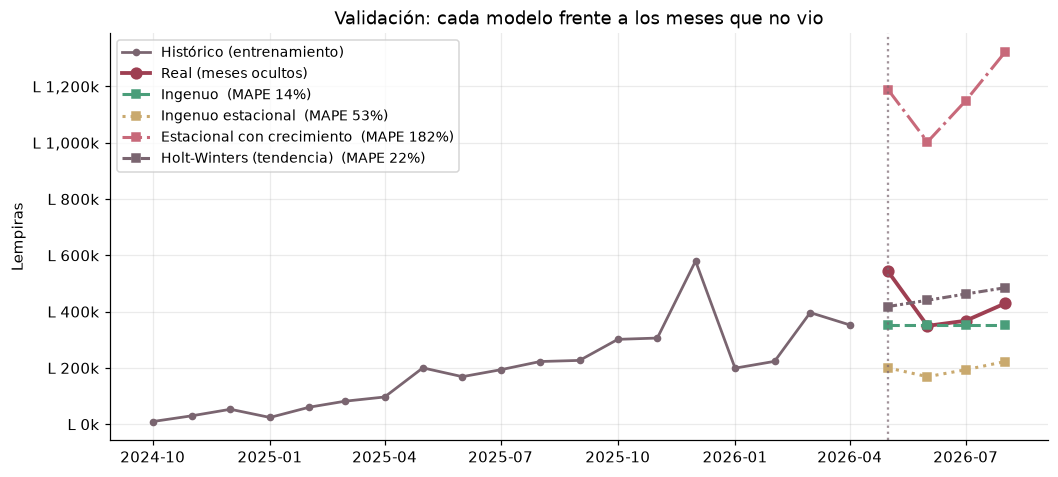

In [8]:
fig, eje = plt.subplots(figsize=(11, 4.8))

eje.plot(entrena.index, entrena.values, marker="o", markersize=4,
         color=GRIS, linewidth=1.8, label="Histórico (entrenamiento)")
eje.plot(prueba.index, prueba.values, marker="o", markersize=7,
         color=ROSA_OSCURO, linewidth=2.5, label="Real (meses ocultos)")

for (nombre, valores), color, estilo in zip(
        predicciones.items(), [VERDE, ORO, ROSA, GRIS], ["--", ":", "-.", (0, (3, 1, 1, 1))]):
    eje.plot(valores.index, valores.values, marker="s", markersize=5,
             color=color, linestyle=estilo, linewidth=2,
             label=f"{nombre}  (MAPE {comparacion.loc[nombre, 'MAPE']:.0f}%)")

eje.axvline(prueba.index[0], color=GRIS, linestyle=":", alpha=0.7)
eje.set_title("Validación: cada modelo frente a los meses que no vio")
eje.set_ylabel("Lempiras")
eje.yaxis.set_major_formatter(lambda x, _: f"L {x/1000:,.0f}k")
eje.legend(fontsize=9)

guardar("17_validacion_proyeccion")

### El modelo más simple gana, y eso dice algo

El resultado no es el esperado, y conviene leerlo con atención porque enseña más que si
hubiera ganado el modelo sofisticado.

**Gana el ingenuo**, que se limita a repetir el último mes. Con una serie corta y en
crecimiento, «el mes que viene se parecerá a este» resulta difícil de batir: cualquier
modelo más ambicioso tiene que estimar parámetros con muy pocos datos, y cada parámetro mal
estimado es error añadido.

**El ingenuo estacional falla** porque el negocio ha crecido mucho: el mismo mes del año
pasado corresponde a un negocio bastante más pequeño, así que se queda sistemáticamente
corto.

**Y «estacional con crecimiento» se dispara.** Corrige lo anterior multiplicando por la tasa
de crecimiento interanual... que en esta serie resulta ser de casi **6x**, porque los
primeros meses del histórico son el arranque del negocio, cuando la clientela apenas se
estaba formando. El modelo confunde *arrancar* con *crecer*, extrapola ese ritmo, y proyecta
más del doble de lo que ocurre.

Es un error instructivo y se deja a la vista a propósito: **extrapolar la tasa de
crecimiento de una fase de arranque es una de las formas más fáciles de producir una
proyección absurda**, y la gráfica lo muestra mejor que cualquier explicación.

**Una advertencia sobre el propio resultado.** La validación usa cuatro meses. Con tan pocos
puntos, la ventaja del modelo ingenuo podría deberse en parte al azar. Lo que sí se puede
afirmar con seguridad es lo contrario: los modelos que fallan por mucho, fallan de verdad.

---
## 4. Proyección de los próximos meses

El modelo ganador se reentrena con **toda** la serie —incluidos los meses que sirvieron de
prueba— y proyecta hacia adelante. Aprovechar todo el histórico disponible es lo correcto
una vez que ya se sabe qué modelo usar.

In [9]:
mejor_nombre = comparacion["MAPE"].idxmin()
print(f"  modelo con menor error: {mejor_nombre}  (MAPE {comparacion.loc[mejor_nombre, 'MAPE']:.1f}%)\n")

MESES_A_PROYECTAR = 3

futuro = pd.date_range(serie.index[-1], periods=MESES_A_PROYECTAR + 1, freq="MS")[1:]

if mejor_nombre == "Holt-Winters (tendencia)":
    modelo_final = ExponentialSmoothing(
        serie, trend="add", seasonal=None, initialization_method="estimated",
    ).fit()
    proyeccion = modelo_final.forecast(MESES_A_PROYECTAR)
elif mejor_nombre == "Estacional con crecimiento":
    factor_final = crecimiento_anual(serie)
    print(f"  crecimiento interanual con toda la serie: {factor_final:.2f}x")
    proyeccion = pd.Series(
        [serie.iloc[-12 + i] * factor_final for i in range(MESES_A_PROYECTAR)], index=futuro)
elif mejor_nombre == "Ingenuo estacional":
    proyeccion = pd.Series(
        [serie.iloc[-12 + i] for i in range(MESES_A_PROYECTAR)], index=futuro)
else:
    proyeccion = pd.Series([serie.iloc[-1]] * MESES_A_PROYECTAR, index=futuro)

# Banda de incertidumbre a partir del error observado en la validacion. No es un
# intervalo de confianza estadistico: es el margen que el modelo erro de verdad
# sobre meses que no habia visto, que para decidir una compra es mas util.
margen = comparacion.loc[mejor_nombre, "MAE"]

resultado = pd.DataFrame({
    "proyeccion": proyeccion.round(0),
    "minimo": (proyeccion - margen).clip(lower=0).round(0),
    "maximo": (proyeccion + margen).round(0),
})
resultado.index = resultado.index.strftime("%Y-%m")

resultado.style.format("L {:,.0f}")

  modelo con menor error: Ingenuo  (MAPE 14.4%)



,proyeccion,minimo,maximo
2026-09,"L 429,260","L 358,085","L 500,435"
2026-10,"L 429,260","L 358,085","L 500,435"
2026-11,"L 429,260","L 358,085","L 500,435"


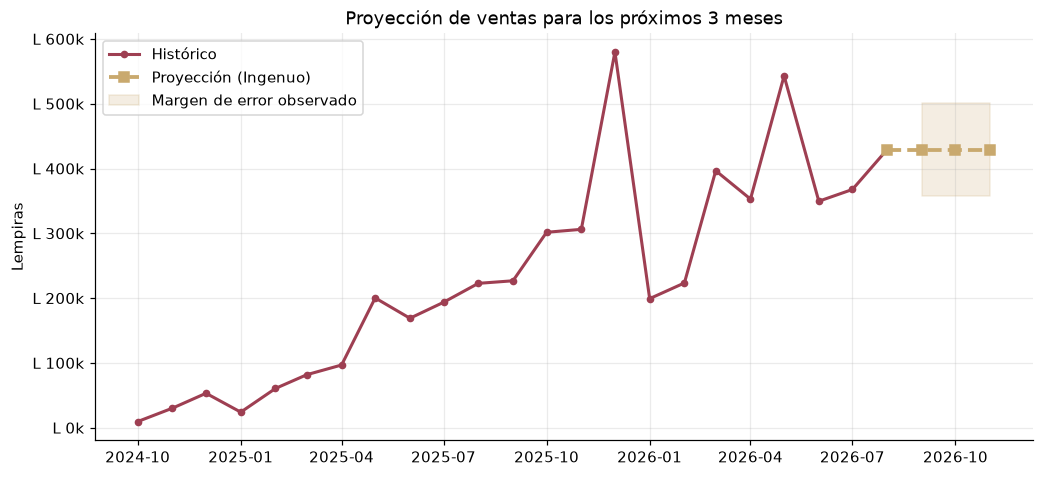

In [10]:
fig, eje = plt.subplots(figsize=(11, 4.8))

eje.plot(serie.index, serie.values, marker="o", markersize=4,
         color=ROSA_OSCURO, linewidth=2, label="Histórico")

union = pd.concat([serie.iloc[-1:], proyeccion])
eje.plot(union.index, union.values, marker="s", markersize=6,
         color=ORO, linestyle="--", linewidth=2.5, label=f"Proyección ({mejor_nombre})")

eje.fill_between(proyeccion.index,
                 (proyeccion - margen).clip(lower=0), proyeccion + margen,
                 color=ORO, alpha=0.2, label="Margen de error observado")

eje.set_title(f"Proyección de ventas para los próximos {MESES_A_PROYECTAR} meses")
eje.set_ylabel("Lempiras")
eje.yaxis.set_major_formatter(lambda x, _: f"L {x/1000:,.0f}k")
eje.legend()

guardar("18_proyeccion")

---
## 5. Qué decisión permite tomar

**La proyección se traduce en una cantidad de mercadería.** Conocido el volumen esperado del
mes y el margen habitual del negocio, se estima cuánto producto hay que tener disponible.

**Los factores estacionales dicen cuándo comprar con antelación.** Mayo y diciembre exigen
preparar inventario semanas antes; enero y febrero permiten reducirlo y liberar capital.
Con la salvedad de que, en este histórico, esa estacionalidad **se ve pero todavía no se
puede aprovechar** para proyectar: hace falta un tercer año para estimarla con fiabilidad.

**El margen de error acompaña siempre al número.** Una proyección sin margen invita a
tomarla como certeza. Con él, la decisión de compra puede ser deliberada: comprar para el
escenario bajo si el capital está ajustado, para el alto si se prefiere no quedarse sin
producto.

### Limitaciones, sin adornos

1. **Dos ciclos anuales son muy poco.** Cada factor estacional se estima con dos
   observaciones, y ni siquiera alcanzan para que statsmodels acepte descomponer la serie.
   La estacionalidad se ve en los datos, pero **no se pudo explotar** para mejorar la
   proyección: los dos modelos que la usan quedaron por detrás del que la ignora.
2. **La serie incluye el arranque del negocio,** y eso hizo fracasar a un modelo. Los
   primeros meses reflejan una clientela que todavía se estaba formando; tomar ese ritmo
   por crecimiento sostenido llevó a proyectar casi el triple de lo real. Con más histórico
   —o descartando la fase de arranque— ese modelo probablemente funcionaría.
3. **Ningún modelo de serie de tiempo anticipa lo que no está en el histórico.** Un cambio
   de proveedor, una competidora nueva en la zona o una crisis no aparecen en los datos
   pasados, y el modelo seguirá proyectando como si nada hubiera cambiado.
4. **Los datos son sintéticos.** La estacionalidad detectada es la que se simuló al generar
   el conjunto. Con datos reales el patrón puede ser otro; lo que se traslada es el método,
   no los coeficientes.

---

**Siguiente:** el dashboard, que reúne el riesgo por clienta y esta proyección en una sola
pantalla.